In [1]:
import tensorflow as tf
from tensorflow import keras
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

Importación de librerias.

In [2]:
(imagenes_entrenamiento, etiquetas_entrenamiento ), (imagenes_verificacion, etiquetas_verificacion) = keras.datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


Carga de conjunto de datos de imagenes para entrenamiento. 50.000 fotos en color de 32x32 pixels de aviones, trenes, autos, etc con etiquetas. 10000 fotos para testear

In [3]:
print(etiquetas_entrenamiento.shape, imagenes_entrenamiento.shape)

(50000, 1) (50000, 32, 32, 3)


In [4]:
imagenes_entrenamiento, imagenes_verificacion = imagenes_entrenamiento / 255.0, imagenes_verificacion  / 255.0

AGREGADO: Estandarizacion entre 0s y 1s

In [5]:
nombres_clases = ['airplane','automobile','bird','cat','deer',
                  'dog','frog','horse','ship','truck']

Funcion para mostrar imagenes en miniatura.

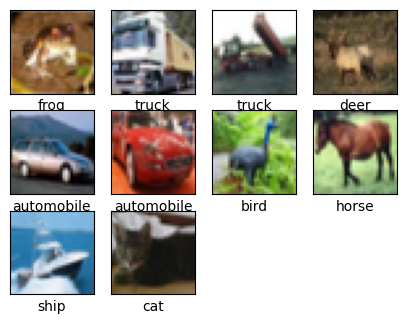

In [6]:
import matplotlib.pyplot as plt
def mostrar():
  plt.figure(figsize=(5,5))
  for i in range(10):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagenes_entrenamiento[i], cmap=plt.cm.binary)
    plt.xlabel(nombres_clases[etiquetas_entrenamiento[i][0]])
  plt.show()
mostrar()

Una capa de entrada para imagenes de 32x32 pixels con 3 dimensiones de colores.
Dos capas convolucionales para extraer caracteristicas, con 32 filtros de 3x3. Quitando relleno que no se ajusta.
Dos capas de agrupamiento con filtros de 2x2 para achicar la anterior.

Una capa complemtamente conectada (densa) con 64 neuronas.
Una capa de salida con 10 neuronas para clasificar.

In [7]:
capa = keras.layers
modelo = keras.models.Sequential()
modelo.add(capa.Conv2D(32, (3,3), strides=(1,1), padding="valid", activation='relu',
                       input_shape=(32,32,3)))
modelo.add(capa.MaxPool2D(2,2))
modelo.add(capa.Conv2D(32, 3, activation='relu' ))
modelo.add(capa.MaxPool2D(2,2))
modelo.add(capa.Flatten())

modelo.add(capa.Dense(64, activation='relu'))
modelo.add(capa.Dense(10))

modelo.summary()  #(3x3xC+1)x32 = 896 (C=Canales) 32 filtros. kernel 3x3

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,586 (330.41 KB)

 Trainable params: 84,586 (330.41 KB)

 Non-trainable params: 0 (0.00 B)

Configuracion del modelo

In [8]:
modelo.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

Entrenamiento (creación del modelo)

In [9]:
modelo.fit(imagenes_entrenamiento, etiquetas_entrenamiento,
           epochs=10, batch_size=64)

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 70ms/step - accuracy: 0.4359 - loss: 1.5563
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 60ms/step - accuracy: 0.5630 - loss: 1.2372
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 61ms/step - accuracy: 0.6133 - loss: 1.1021


Loss se busca el número mas bajo. Accuracy el más alto

In [10]:
modelo.evaluate(imagenes_verificacion, etiquetas_verificacion,
                batch_size=64)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6247 - loss: 1.0704


[1.0704407691955566, 0.6247000098228455]

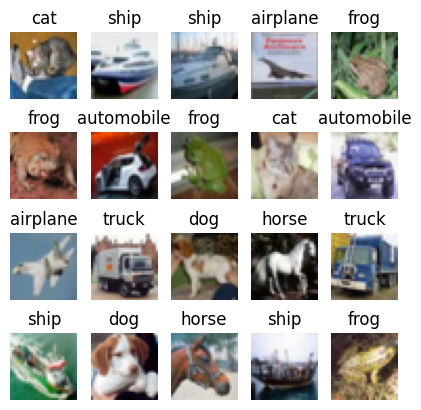

In [13]:
#Parte de la imagenes de prueba
plt.figure(figsize=(5,5))

for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(imagenes_verificacion[i])
    plt.axis("off")
    plt.title(nombres_clases[etiquetas_verificacion[i][0]])

plt.show()

In [20]:
#predict()
#Esto crea el botón para seleccionar una imagen.


archivo = files.upload()

Saving caballo.jpg to caballo.jpg


PREDICCIÓN DE IMÁGENES EXTERNAS

A continuación se permite cargar una imagen local para que el modelo entrenado realice una clasificación dentro de las 10 categorías de CIFAR-10.


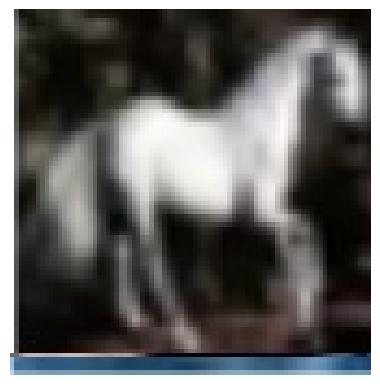

In [21]:
#Procesar la imagen

nombre_archivo = list(archivo.keys())[0]

img = Image.open(nombre_archivo)

plt.imshow(img)
plt.axis('off')
plt.show()

In [22]:
#Adaptar la imagen al tamaño del modelo
img = img.resize((32,32))

img_array = np.array(img)

# por si viene con canal alfa
if img_array.shape[-1] == 4:
    img_array = img_array[:,:,:3]

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


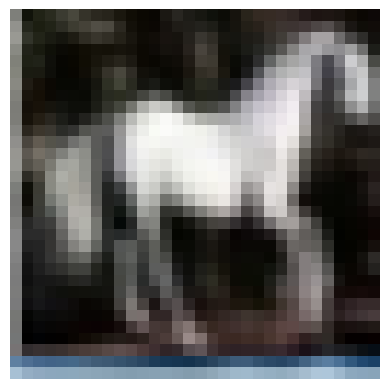

Predicción del modelo: horse


In [23]:
#Realizar la predicción
prediccion = modelo.predict(img_array)

indice = np.argmax(prediccion)

plt.imshow(img)
plt.axis("off")
plt.show()

print(f"Predicción del modelo: {nombres_clases[indice]}")

In [24]:
# Mostrar probabilidades, Así demuestra que entendés cómo decide la red.

probabilidades = tf.nn.softmax(prediccion[0])

df = pd.DataFrame({
    "Clase": nombres_clases,
    "Probabilidad": probabilidades.numpy()
})

df = df.sort_values(
    "Probabilidad",
    ascending=False
)

print(df)

        Clase  Probabilidad
7       horse      0.943720
3         cat      0.015278
5         dog      0.012131
4        deer      0.009242
2        bird      0.007655
9       truck      0.004370
6        frog      0.003676
0    airplane      0.002408
1  automobile      0.001390
8        ship      0.000132


In [25]:
display(df)

,Clase,Probabilidad
7,horse,0.943720
3,cat,0.015278
5,dog,0.012131
4,deer,0.009242
2,bird,0.007655
9,truck,0.004370
6,frog,0.003676
0,airplane,0.002408
1,automobile,0.001390
8,ship,0.000132
